In this notebook, we build a Tensorflow input pipeline for the images and labels we want to use to train MiMi-Net. We then build the model with the parameters we need for our objective. The model is built to learn 3 classes: Class 0 = non-feature, Class 1 = crevasse field, Class 2 = supraglacial stream/lake. The image labels have these 3 classes as pixel values of 0-2. We then train the model for a certain number of epochs. The notebook outputs performance metrics at each epoch run. After the model training is completed, we visualize the accuracy and loss plots of training and validation datasets. We then evaluate the model performance by calculating the IoU and F1-score metrics. Finally, we visually assess the model performance by testing the model to predict on the validation dataset.

# Import relevant packages

In [1]:
#### Magic command to load tensorboard extension (only for users on local machine)
# %load_ext tensorboard
import os
# Mute TF Bug Warnings (Before importing tensorflow)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import sys
# Appending the U-net package folder
sys.path.append("./bin/")
import unet
from unet import utils
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import losses, metrics
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Activation, ReLU
from tensorflow.keras.layers import BatchNormalization, Conv2DTranspose, Concatenate
from tensorflow.keras.models import Model, Sequential
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import jaccard_score, classification_report
print(f"Tensorflow ver. {tf.__version__}")

Tensorflow ver. 2.15.0


## TF input pipeline for MiMi-Net

function to read image and mask from file

In [2]:
IMG_SIZE = (512,512)

def read_image(image_name):
    image = tf.io.read_file(image_name)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)/255.0
    return image
    
def read_mask(mask_name):    
    mask = tf.io.read_file(mask_name)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE)
    mask = tf.cast(mask, tf.uint8)
    #mask = tf.expand_dims(mask, axis=-1)
    return mask

Create TRAIN TF dataset of Images and Labels separately and then map the files to read functions of images and labels

In [3]:
train_image_dataset = tf.data.Dataset.list_files(["./bin/gris/Images/Train/*.png"], shuffle=False)
train_image_dataset = train_image_dataset.map(read_image, num_parallel_calls=tf.data.AUTOTUNE)
train_label_dataset = tf.data.Dataset.list_files(["./bin/gris/Labels/Train/*.png"], shuffle=False)
train_label_dataset = train_label_dataset.map(read_mask, num_parallel_calls=tf.data.AUTOTUNE)

Combine both datasets

In [4]:
train_ds = tf.data.Dataset.zip((train_image_dataset,train_label_dataset))

Create VALIDATION TF dataset of Images and Labels separately and then map the files to read functions of images and labels

In [5]:
valid_image_dataset = tf.data.Dataset.list_files("./bin/gris/Images/Valid/*.png", shuffle=False)
valid_image_dataset = valid_image_dataset.map(read_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_label_dataset = tf.data.Dataset.list_files("./bin/gris/Labels/Valid/*.png", shuffle=False)
valid_label_dataset = valid_label_dataset.map(read_mask, num_parallel_calls=tf.data.AUTOTUNE)

Combine both datasets

In [6]:
valid_ds = tf.data.Dataset.zip((valid_image_dataset,valid_label_dataset))

To view the shape of the dataset

In [7]:
#for element in train_ds:
#print(element)

## Build MiMi-Net with parameters

In [8]:
miminet_model = unet.build_model(nx = 512, ny = 512,
                              channels=1,
                              num_classes=3,
                              layer_depth=3,
                              filters_root=16,
                              pool_size=2,
                            ## change dropout rate as required; For SGD optimizer, use 0.1; For Adam optimizer, use 0.04
                              dropout_rate=0.05,
                              padding="same",
                              activation="relu",
                              kernel_initializer='glorot_uniform',
                              kernel_regularizer=tf.keras.regularizers.L1L2(l1=0.0, l2=0.01)
)

unet.finalize_model(miminet_model,
                    loss=losses.SparseCategoricalCrossentropy(from_logits=False),
                    ## change optimizer type/parameters as required
                    #optimizer=tf.keras.optimizers.experimental.SGD(learning_rate=0.06, momentum=0.2),
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002, epsilon=0.01),
                    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(),
                            tf.keras.metrics.IoU(num_classes=3,target_class_ids=[1],ignore_class=[0]),
                            tf.keras.metrics.MeanIoU(num_classes=3,sparse_y_true=True,sparse_y_pred=False)],
                    auc=False,
)


View model structure

In [9]:
#miminet_model.summary()

### Train Model

In [10]:
# Suppress unnecessary warnings
from absl import logging
logging.set_verbosity(logging.ERROR)

Set number of epochs and batch size to run the model

In [11]:
EPOCHS = 2
### Set "tensorboard_images_callback = False" for lower memory usage, defaults to True
trainer = unet.Trainer(name="./bin/crevasse_models", tensorboard_images_callback=False)
trainer.fit(miminet_model,
            train_dataset = train_ds,
            validation_dataset = valid_ds,
            epochs=EPOCHS,
            batch_size=1) # Set batch size per epoch, default is 1

1/1 [==============================] - 1s 1s/step
Epoch 1/2
36/36 [==============================] - ETA: 0s - loss: 0.9556 - sparse_categorical_accuracy: 0.7305 - io_u: 0.0000e+00 - mean_io_u: 0.2441INFO:tensorflow:Assets written to: bin/crevasse_models/2025_02_15T19_37_34/assets


INFO:tensorflow:Assets written to: bin/crevasse_models/2025_02_15T19_37_34/assets


36/36 [==============================] - 10s 205ms/step - loss: 0.9556 - sparse_categorical_accuracy: 0.7305 - io_u: 0.0000e+00 - mean_io_u: 0.2441 - val_loss: 0.7370 - val_sparse_categorical_accuracy: 0.7785 - val_io_u: 0.0000e+00 - val_mean_io_u: 0.2595 - learning_rate: 0.0070
Epoch 2/2
36/36 [==============================] - ETA: 0s - loss: 0.7992 - sparse_categorical_accuracy: 0.7316 - io_u: 0.0000e+00 - mean_io_u: 0.2439INFO:tensorflow:Assets written to: bin/crevasse_models/2025_02_15T19_37_34/assets


INFO:tensorflow:Assets written to: bin/crevasse_models/2025_02_15T19_37_34/assets


36/36 [==============================] - 6s 174ms/step - loss: 0.7992 - sparse_categorical_accuracy: 0.7316 - io_u: 0.0000e+00 - mean_io_u: 0.2439 - val_loss: 0.6529 - val_sparse_categorical_accuracy: 0.7785 - val_io_u: 0.0000e+00 - val_mean_io_u: 0.2595 - learning_rate: 0.0070


In [ ]:
### If you are running this notebook on your local machine, you can utilize Tensorboard to monitor model training progress
### Launch Tensorboard with the appropriate log directory (if subdirectories are not mentioned, then all runs will be displayed)
### Also mention port: could be 6007, 6008 onwards. The default is 6006. In case if a tensorboard is already running, use a different port to launch a new instance ig
# %tensorboard --logdir crevasse_data --port=6006

### Make Accuracy and Loss Plots

##### Training and Validation Accuracy L-curve

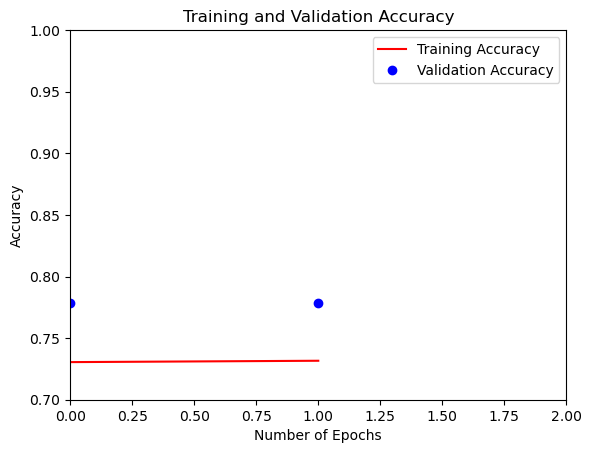

In [12]:
acc = miminet_model.history.history['sparse_categorical_accuracy']
val_acc = miminet_model.history.history['val_sparse_categorical_accuracy']
# produces L-curve (monitor elbow of the L)
plt.figure()
plt.plot( acc, 'r', label='Training Accuracy')
plt.plot( val_acc, 'bo', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Number of Epochs')
plt.ylabel('Accuracy')
plt.xlim([0, EPOCHS])
plt.ylim([0.7, 1])
plt.legend()
plt.show()

##### Training and Validation Loss (L-curve)

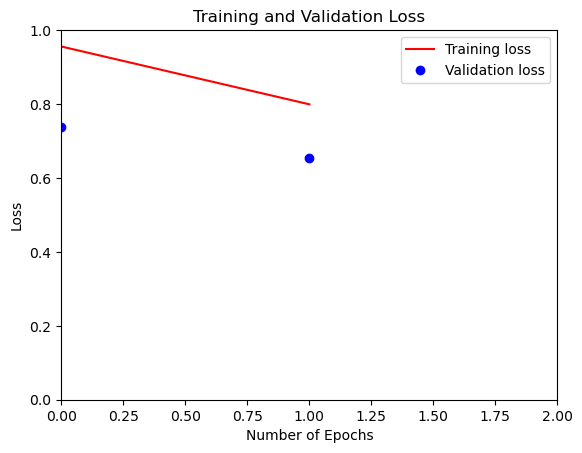

In [13]:
loss = miminet_model.history.history['loss']
val_loss = miminet_model.history.history['val_loss']
# produces L-curve (monitor elbow of the L)
plt.figure()
plt.plot( loss, 'r', label='Training loss')
plt.plot( val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Number of Epochs')
plt.ylabel('Loss')
plt.xlim([0, EPOCHS])
plt.ylim([0, 1])
plt.legend()
plt.show()

### Get IoU (Jaccard Similarity Score) and Classification Report (Precision, Recall and F1 Score) for each class

Generate predictions from model using TF dataset and process them to input format of scikit-learn modules

In [14]:
all_predictions = []
for i, (image) in enumerate (train_ds):
    preds = miminet_model.predict(train_ds.batch(batch_size=1),verbose=0)
    prediction_image = np.argmax(preds[i,...], axis=-1)
    ## Convert to 8-bit so that values are 0,1,2 to match labels
    prediction_image = prediction_image.astype(np.uint8)
    ### prediction image comes out as numpy array so only flatten to match with true labels
    all_predictions.extend(prediction_image.flatten())
true_labels = []
for images, labels in train_ds:
    ### convert labels to numpy array and flatten to match with predicted labels
    true_labels.extend(np.array(labels).flatten())

Calculate Jaccard similarity score for each class

In [15]:
jaccard_scores = jaccard_score(true_labels, all_predictions, average=None, zero_division=0)
print("Jaccard similarity scores / IoU per class:", jaccard_scores)

Jaccard similarity scores per class: [0.73162874 0.         0.        ]


##### Calculate overall Jaccard similarity score

Choose an appropriate averaging method based on your needs (e.g., 'macro', 'weighted').

'micro': globally by counting the total true positives, false negatives and false positives.

'macro': for each label, and find their unweighted mean. This does not take label imbalance into account.

'weighted': for each label, and find their average, weighted by support (the number of true instances for each label). This alters ‘macro’ to account for label imbalance.

In [16]:
average_jaccard_score = jaccard_score(true_labels, all_predictions, average='weighted', zero_division=0)
print("Average Jaccard similarity score / Mean IoU:", average_jaccard_score)

Average Jaccard similarity score: 0.5352806071363779


##### Generate a classification report

In [17]:
print("Classification report:\n", classification_report(true_labels, all_predictions, zero_division=0))

Classification report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.85   6904515
           1       0.00      0.00      0.00   2179701
           2       0.00      0.00      0.00    352968

    accuracy                           0.73   9437184
   macro avg       0.24      0.33      0.28   9437184
weighted avg       0.54      0.73      0.62   9437184



### Predict on Validation Dataset

In the case if the kernel dies, load the pre-trained saved model using path 
(also run the cells of import packages and import datasets prior to this cell)

In [18]:
#miminet_model = tf.keras.models.load_model('./bin/crevasse_models/2024_03_11T06_30_40')

4/4 [==============================] - 0s 21ms/step


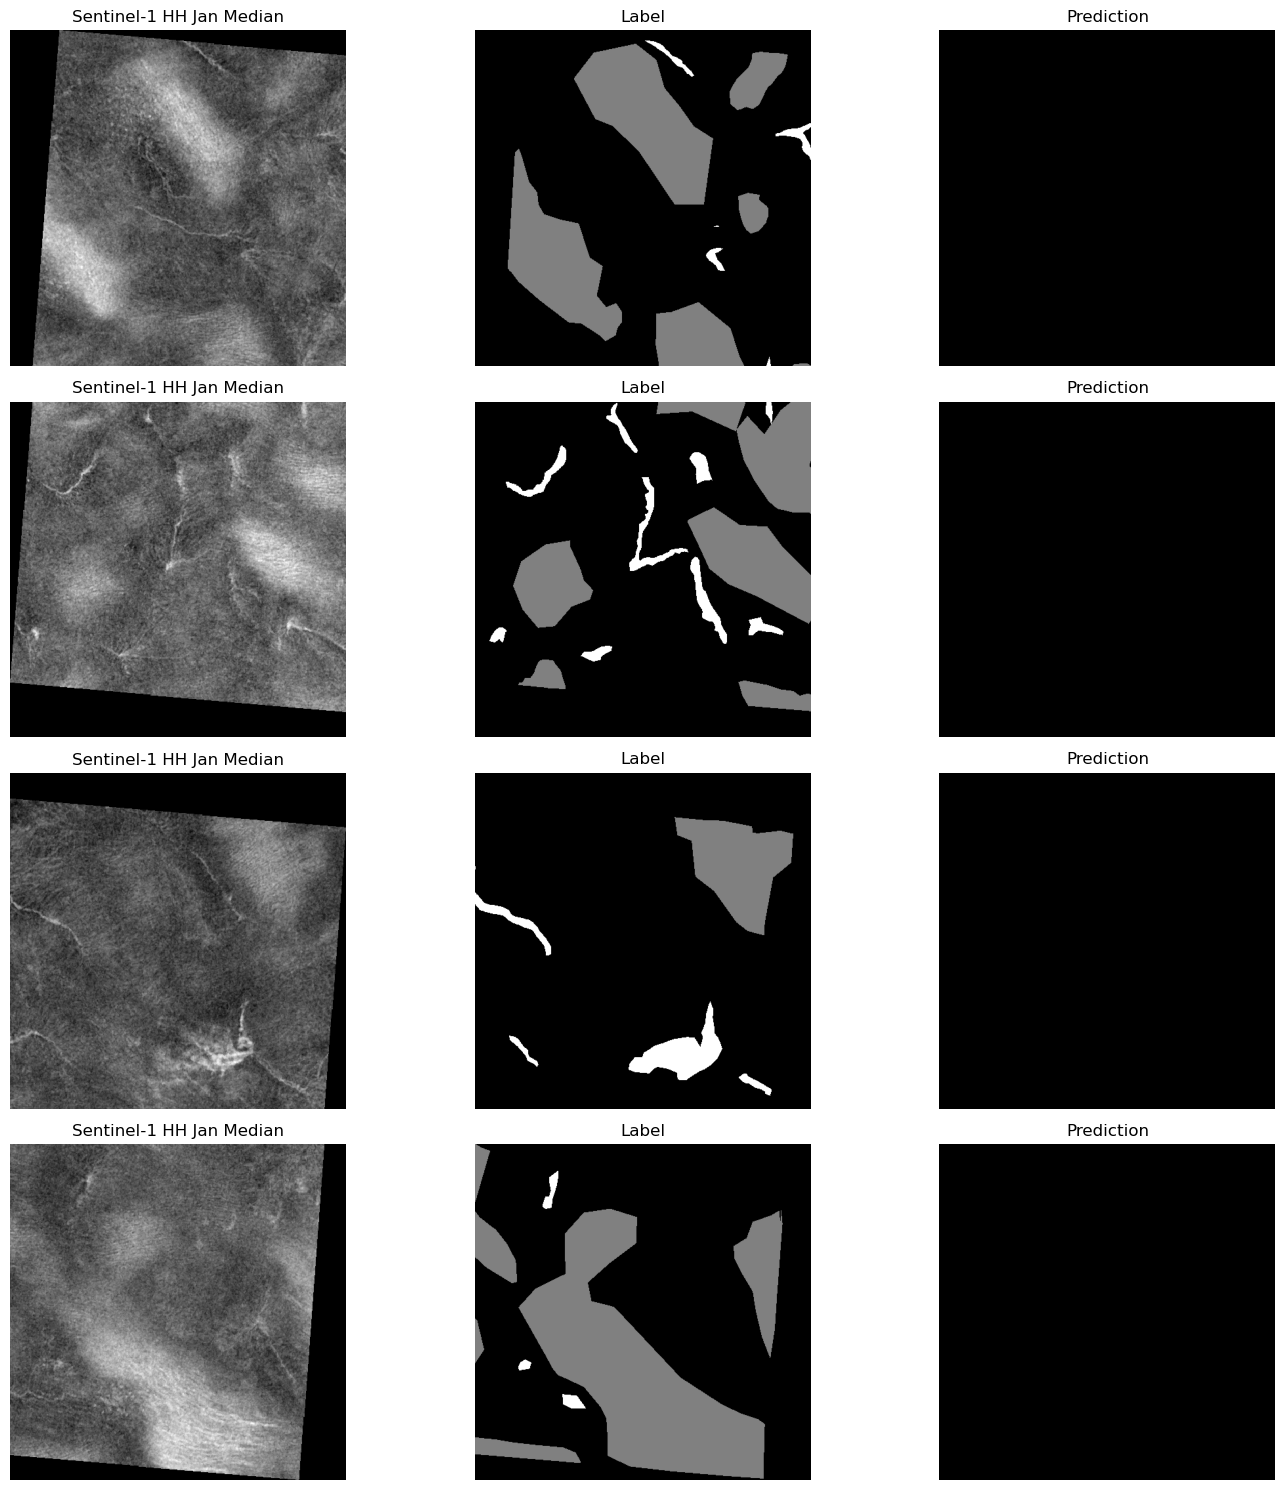

In [19]:

valid_test = miminet_model.predict(valid_ds.batch(batch_size=1))
#valid_test_evaluation = miminet_model.evaluate(valid_ds.batch(batch_size=1))
fig, ax = plt.subplots(4, 3, sharex=True, sharey=True, figsize=(15,15))
dataset = valid_ds.map(utils.crop_image_and_label_to_shape(valid_test.shape[1:]))

for i, (image, label) in enumerate(dataset.take(4)):
    ax[i][0].imshow(image[..., -1],cmap=plt.cm.gray); ax[i][0].set_title('Sentinel-1 HH Jan Median'); ax[i][0].axis('off')
    ax[i][1].imshow(label[...],cmap=plt.cm.gray); ax[i][1].set_title('Label'); ax[i][1].axis('off')
    ax[i][2].imshow(np.argmax(valid_test[i,...],axis=-1),cmap=plt.cm.gray); ax[i][2].set_title('Prediction'); ax[i][2].axis('off')
plt.tight_layout()